# Berlin Logistics Intelligence

## Project Overview

Berlin Logistics Intelligence is an end-to-end data analytics project focused on shipment operations in Berlin.

The project demonstrates a complete workflow from raw data cleaning and validation to exploratory analysis, SQL analysis, and interactive dashboarding.

### Tools
- Python (Pandas)
- SQLite / SQL
- Looker Studio
- Google Colab

## Data Preparation & Quality

The raw dataset contained 510 shipment records and 7 columns.

Data preparation included:

- Parsing the malformed CSV structure
- Converting numeric fields to appropriate data types
- Removing 1 exact duplicate record
- Normalizing PLZ values to a 5-character text format
- Checking for missing values
- Checking zero values in key numeric fields
- Validating the cleaned dataset before analysis

The final dataset contains **509 shipment records** with **226 unique PLZ values**.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [43]:
df = pd.read_csv('/content/sample_data/Berlin_Traffic_data _set .csv')

df.head()

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
0,"15745,182.0,3,""Abholung,Lieferung,Service"",38....",NaN,NaN,NaN,NaN,NaN,NaN
1,"15745,68.0,2,""Abholung,Lieferung,Service"",15.9...",NaN,NaN,NaN,NaN,NaN,NaN
2,"15711,54.0,1,""Abholung,Lieferung,Service"",14.4...",NaN,NaN,NaN,NaN,NaN,NaN
3,"15711,69.0,2,""Abholung,Lieferung,Service"",14.4...",NaN,NaN,NaN,NaN,NaN,NaN
4,"15711,676.0,5,""Abholung,Lieferung,Service"",35....",NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
df.PLZ


,PLZ
0,"15745,182.0,3,""Abholung,Lieferung,Service"",38...."
1,"15745,68.0,2,""Abholung,Lieferung,Service"",15.9..."
2,"15711,54.0,1,""Abholung,Lieferung,Service"",14.4..."
3,"15711,69.0,2,""Abholung,Lieferung,Service"",14.4..."
4,"15711,676.0,5,""Abholung,Lieferung,Service"",35...."
...,...
505,"10965,314.0,2,""Abholung,Lieferung,Service"",21...."
506,"10967,116.0,2,""Abholung,Lieferung,Service"",21...."
507,"10999,56.0,2,""Abholung,Lieferung,Service"",15.8..."
508,13347


# New section

In [46]:
df.columns


Index(['PLZ', 'Gesamtgewicht pro Sendung', 'Anzahl Verpackungseinheit',
       'Auftragsart', 'Distanz (in m)', 'building_levels_avg',
       'parking_count'],
      dtype='object')

In [47]:
with open("/content/sample_data/Berlin_Traffic_data _set .csv", "r") as f:
    print(f.readline())
    print(f.readline(
))


PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count

"15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"



In [48]:
pd.read_csv("/content/sample_data/Berlin_Traffic_data _set .csv", quotechar='"'
)


,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
0,"15745,182.0,3,""Abholung,Lieferung,Service"",38....",NaN,NaN,NaN,NaN,NaN,NaN
1,"15745,68.0,2,""Abholung,Lieferung,Service"",15.9...",NaN,NaN,NaN,NaN,NaN,NaN
2,"15711,54.0,1,""Abholung,Lieferung,Service"",14.4...",NaN,NaN,NaN,NaN,NaN,NaN
3,"15711,69.0,2,""Abholung,Lieferung,Service"",14.4...",NaN,NaN,NaN,NaN,NaN,NaN
4,"15711,676.0,5,""Abholung,Lieferung,Service"",35....",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
505,"10965,314.0,2,""Abholung,Lieferung,Service"",21....",NaN,NaN,NaN,NaN,NaN,NaN
506,"10967,116.0,2,""Abholung,Lieferung,Service"",21....",NaN,NaN,NaN,NaN,NaN,NaN
507,"10999,56.0,2,""Abholung,Lieferung,Service"",15.8...",NaN,NaN,NaN,NaN,NaN,NaN
508,13347,223.0,1.0,Lieferung,18.1,4.8,58.0


In [49]:
df.iloc[0]


,0
PLZ,"15745,182.0,3,""Abholung,Lieferung,Service"",38...."
Gesamtgewicht pro Sendung,NaN
Anzahl Verpackungseinheit,NaN
Auftragsart,NaN
Distanz (in m),NaN
building_levels_avg,NaN
parking_count,NaN


In [50]:
df.iloc[508]

,508
PLZ,13347
Gesamtgewicht pro Sendung,223.0
Anzahl Verpackungseinheit,1.0
Auftragsart,Lieferung
Distanz (in m),18.1
building_levels_avg,4.8
parking_count,58.0


In [51]:
with open("/content/sample_data/Berlin_Traffic_data _set .csv", "r") as f:
    for i in range(3):
        print(repr(f.readline()))

'PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count\n'
'"15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"\n'
'"15745,68.0,2,""Abholung,Lieferung,Service"",15.9,1.2,14.0"\n'


In [52]:
with open("/content/sample_data/Berlin_Traffic_data _set .csv", "r") as f:
    header = f.readline()
    line = f.readline()

print(line)

"15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"



In [53]:
clear_line = line.strip()

In [54]:
print(clear_line)

"15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"


In [55]:
clean1_line = line.strip('"')

In [56]:
print(clean1_line)

15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"



In [57]:
clean_line = line.strip().strip('"')
print(clean_line)

15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0


In [58]:
import csv

In [59]:
reader = csv.reader([clean_line])

In [60]:
row = next(reader)
print(row)

['15745', '182.0', '3', 'Abholung', 'Lieferung', 'Service""', '38.7', '2.5', '20.0']


In [61]:
with open("/content/sample_data/Berlin_Traffic_data _set .csv", "r", encoding="utf-8") as f:
    for i in range(3):
        print(repr(f.readline()))

'PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count\n'
'"15745,182.0,3,""Abholung,Lieferung,Service"",38.7,2.5,20.0"\n'
'"15745,68.0,2,""Abholung,Lieferung,Service"",15.9,1.2,14.0"\n'


In [62]:
import pandas as pd

df = pd.read_csv(
    "/content/sample_data/Berlin_Traffic_data _set .csv",
    header=0,
    quotechar='"'
)

print(df.head())
print(df.shape)

                                                 PLZ  \
0  15745,182.0,3,"Abholung,Lieferung,Service",38....   
1  15745,68.0,2,"Abholung,Lieferung,Service",15.9...   
2  15711,54.0,1,"Abholung,Lieferung,Service",14.4...   
3  15711,69.0,2,"Abholung,Lieferung,Service",14.4...   
4  15711,676.0,5,"Abholung,Lieferung,Service",35....   

   Gesamtgewicht pro Sendung  Anzahl Verpackungseinheit Auftragsart  \
0                        NaN                        NaN         NaN   
1                        NaN                        NaN         NaN   
2                        NaN                        NaN         NaN   
3                        NaN                        NaN         NaN   
4                        NaN                        NaN         NaN   

   Distanz (in m)  building_levels_avg  parking_count  
0             NaN                  NaN            NaN  
1             NaN                  NaN            NaN  
2             NaN                  NaN            NaN  
3           

In [63]:
print(df.columns.tolist())
print(df.iloc[0, 0])

['PLZ', 'Gesamtgewicht pro Sendung', 'Anzahl Verpackungseinheit', 'Auftragsart', 'Distanz (in m)', 'building_levels_avg', 'parking_count']
15745,182.0,3,"Abholung,Lieferung,Service",38.7,2.5,20.0


In [64]:
import pandas as pd
import csv

file_path = "/content/sample_data/Berlin_Traffic_data _set .csv"

# Read the file line by line
with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Header
columns = next(csv.reader([lines[0].strip()]))

# Clean and parse the data rows
data = []

for line in lines[1:]:
    line = line.strip()

    # Remove the outer quotes around the whole row
    line = line[1:-1]

    # Convert doubled quotes back to normal quotes
    line = line.replace('""', '"')

    # Now parse the actual CSV row
    row = next(csv.reader([line]))

    data.append(row)

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

print(df.head())
print(df.shape)
print(df.columns.tolist())

     PLZ Gesamtgewicht pro Sendung Anzahl Verpackungseinheit  \
0  15745                     182.0                         3   
1  15745                      68.0                         2   
2  15711                      54.0                         1   
3  15711                      69.0                         2   
4  15711                     676.0                         5   

                  Auftragsart Distanz (in m) building_levels_avg parking_count  
0  Abholung,Lieferung,Service           38.7                 2.5          20.0  
1  Abholung,Lieferung,Service           15.9                 1.2          14.0  
2  Abholung,Lieferung,Service           14.4                 1.9          30.0  
3  Abholung,Lieferung,Service           14.4                 1.9          30.0  
4  Abholung,Lieferung,Service           35.0                 1.0           0.0  
(510, 7)
['PLZ', 'Gesamtgewicht pro Sendung', 'Anzahl Verpackungseinheit', 'Auftragsart', 'Distanz (in m)', 'building_levels_avg'

In [65]:
numeric_cols = [
    "PLZ",
    "Gesamtgewicht pro Sendung",
    "Anzahl Verpackungseinheit",
    "Distanz (in m)",
    "building_levels_avg",
    "parking_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PLZ                        510 non-null    int64  
 1   Gesamtgewicht pro Sendung  510 non-null    float64
 2   Anzahl Verpackungseinheit  510 non-null    int64  
 3   Auftragsart                510 non-null    object 
 4   Distanz (in m)             510 non-null    float64
 5   building_levels_avg        510 non-null    float64
 6   parking_count              510 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 28.0+ KB


In [67]:
df.isna().sum()

,0
PLZ,0
Gesamtgewicht pro Sendung,0
Anzahl Verpackungseinheit,0
Auftragsart,0
Distanz (in m),0
building_levels_avg,0
parking_count,0


In [68]:
df.isna().sum()


,0
PLZ,0
Gesamtgewicht pro Sendung,0
Anzahl Verpackungseinheit,0
Auftragsart,0
Distanz (in m),0
building_levels_avg,0
parking_count,0


In [69]:
df.duplicated().sum()

np.int64(1)

In [70]:
df.describe()

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Distanz (in m),building_levels_avg,parking_count
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,11034.662745,102.601961,1.507843,26.076078,3.052157,24.879216
std,5408.545056,135.519376,0.865706,16.775820,2.084065,33.278294
min,115.000000,0.000000,0.000000,1.400000,0.000000,0.000000
25%,10195.000000,26.000000,1.000000,15.900000,1.600000,2.000000
50%,12588.000000,52.000000,1.000000,20.700000,3.100000,12.000000
75%,14391.000000,117.500000,2.000000,30.250000,4.300000,34.000000
max,39524.000000,888.000000,8.000000,99.700000,13.300000,152.200000


In [71]:
df["Auftragsart"].value_counts()

,count
Auftragsart,
"Lieferung,Service",292
"Abholung,Lieferung,Service",137
Lieferung,81


In [72]:
df[df.duplicated(keep=False)]

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
137,12051,81.0,1,"Abholung,Lieferung,Service",14.5,4.2,33.0
138,12051,81.0,1,"Abholung,Lieferung,Service",14.5,4.2,33.0


In [73]:
zero_counts = (df == 0).sum()
zero_counts

,0
PLZ,0
Gesamtgewicht pro Sendung,6
Anzahl Verpackungseinheit,4
Auftragsart,0
Distanz (in m),0
building_levels_avg,72
parking_count,102


In [74]:
df[df["Gesamtgewicht pro Sendung"] == 0]

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
68,10829,0.0,0,"Abholung,Lieferung,Service",17.4,5.0,18.0
136,12157,0.0,0,"Abholung,Lieferung,Service",11.1,4.1,11.0
164,13595,0.0,1,"Lieferung,Service",16.0,0.0,0.0
365,10369,0.0,0,"Lieferung,Service",18.1,5.2,3.0
381,16341,0.0,1,"Lieferung,Service",19.6,1.5,0.0
403,12629,0.0,0,"Lieferung,Service",31.4,4.8,62.0


In [75]:
df[df["Anzahl Verpackungseinheit"] == 0]

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
68,10829,0.0,0,"Abholung,Lieferung,Service",17.4,5.0,18.0
136,12157,0.0,0,"Abholung,Lieferung,Service",11.1,4.1,11.0
365,10369,0.0,0,"Lieferung,Service",18.1,5.2,3.0
403,12629,0.0,0,"Lieferung,Service",31.4,4.8,62.0


In [76]:
df[df["Gesamtgewicht pro Sendung"] == 0]["Auftragsart"].value_counts()

,count
Auftragsart,
"Lieferung,Service",4
"Abholung,Lieferung,Service",2


In [77]:
df[df["building_levels_avg"] == 0]["Auftragsart"].value_counts()

,count
Auftragsart,
"Abholung,Lieferung,Service",32
"Lieferung,Service",31
Lieferung,9


In [78]:
df[df["parking_count"] == 0]["Auftragsart"].value_counts()

,count
Auftragsart,
"Lieferung,Service",57
"Abholung,Lieferung,Service",33
Lieferung,12


In [79]:
df_clean = df.drop_duplicates().copy()

print(df_clean.shape)

(509, 7)


In [80]:
df_clean.duplicated().sum()

np.int64(0)

In [81]:
df_clean.describe()

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Distanz (in m),building_levels_avg,parking_count
count,509.000000,509.000000,509.000000,509.000000,509.000000,509.000000
mean,11032.666012,102.644401,1.508841,26.098821,3.049902,24.863261
std,5413.677646,135.649303,0.866264,16.784452,2.085492,33.309080
min,115.000000,0.000000,0.000000,1.400000,0.000000,0.000000
25%,10179.000000,26.000000,1.000000,15.900000,1.600000,2.000000
50%,12589.000000,52.000000,1.000000,20.700000,3.100000,12.000000
75%,14467.000000,118.000000,2.000000,30.300000,4.300000,34.000000
max,39524.000000,888.000000,8.000000,99.700000,13.300000,152.200000


In [82]:
distance_by_plz = (
    df_clean.groupby("PLZ")["Distanz (in m)"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

distance_by_plz.head(10)

,count,mean,median
PLZ,,,
3048,1,93.50,93.50
3403,1,88.90,88.90
10247,2,75.55,75.55
115,1,71.10,71.10
14624,1,69.40,69.40
10585,1,62.00,62.00
2043,1,57.50,57.50
13349,1,57.20,57.20
13627,1,55.50,55.50


In [83]:
weight_by_plz = (
    df_clean.groupby("PLZ")["Gesamtgewicht pro Sendung"]
    .mean()
    .sort_values(ascending=False)
)

weight_by_plz.head(10)

,Gesamtgewicht pro Sendung
PLZ,
3587,888.0
3403,694.0
12163,511.0
115,502.0
10318,410.0
5732,408.0
827,392.0
551,377.0
13507,350.5


In [84]:
df_clean[df_clean["PLZ"] == 115]

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
258,115,502.0,1,Lieferung,71.1,4.3,9.0


In [85]:
df["PLZ"].astype(str).str.len().value_counts()

,count
PLZ,
5,392
4,112
3,6


In [86]:
df_clean["PLZ"] = df_clean["PLZ"].astype(str).str.zfill(5)

In [87]:
short_plz = (
    df_clean[df_clean["PLZ"].astype(str).str.len() < 5]["PLZ"]
    .value_counts()
    .sort_index()
)

short_plz

,count
PLZ,


In [88]:
df_clean[df_clean["PLZ"].astype(str).str.len() < 5][
    ["PLZ", "Gesamtgewicht pro Sendung", "Auftragsart", "Distanz (in m)"]
]

,PLZ,Gesamtgewicht pro Sendung,Auftragsart,Distanz (in m)


In [89]:
short_plz = (
    df[df["PLZ"].astype(str).str.len() < 5]
    [["PLZ", "Gesamtgewicht pro Sendung", "Auftragsart", "Distanz (in m)"]]
    .sort_values("PLZ")
)

short_plz

,PLZ,Gesamtgewicht pro Sendung,Auftragsart,Distanz (in m)
258,115,502.0,Lieferung,71.1
327,318,58.0,Lieferung,18.2
413,318,19.0,Lieferung,14.3
400,405,82.0,Lieferung,25.7
257,551,377.0,Lieferung,17.2
...,...,...,...,...
115,4621,24.0,Lieferung,20.0
114,4621,65.0,Lieferung,13.1
185,4974,87.0,Lieferung,14.3
184,4979,120.0,Lieferung,26.3


In [90]:
short_plz_counts = (
    df[df["PLZ"].astype(str).str.len() < 5]["PLZ"]
    .value_counts()
    .sort_index()
)

short_plz_counts

,count
PLZ,
115,1
318,2
405,1
551,1
827,1
...,...
4612,1
4621,3
4974,1


In [91]:
short_plz_counts.to_frame("count")

,count
PLZ,
115,1
318,2
405,1
551,1
827,1
...,...
4612,1
4621,3
4974,1


In [92]:
short_values = sorted(short_plz_counts.index.tolist())
short_values

[115,
 318,
 405,
 551,
 827,
 2043,
 2045,
 2049,
 2051,
 2053,
 2055,
 2099,
 2101,
 2103,
 2105,
 2107,
 2109,
 2203,
 2249,
 2277,
 2305,
 2307,
 2309,
 2347,
 2349,
 2351,
 2353,
 2357,
 2359,
 2435,
 2437,
 2439,
 2459,
 2489,
 2526,
 2527,
 2529,
 2555,
 2557,
 2587,
 2623,
 3042,
 3044,
 3046,
 3048,
 3050,
 3052,
 3055,
 3099,
 3222,
 3347,
 3403,
 3587,
 4163,
 4167,
 4513,
 4532,
 4612,
 4621,
 4974,
 4979,
 5732]

In [93]:
three_digit_plz = df[df["PLZ"].astype(str).str.len() == 3]["PLZ"].value_counts().sort_index()

four_digit_plz = df[df["PLZ"].astype(str).str.len() == 4]["PLZ"].value_counts().sort_index()

print("3-digit PLZ:")
print(three_digit_plz)

print("\n4-digit PLZ:")
print(four_digit_plz)

3-digit PLZ:
PLZ
115    1
318    2
405    1
551    1
827    1
Name: count, dtype: int64

4-digit PLZ:
PLZ
2043     1
2045     1
2049     4
2051     3
2053     1
2055     1
2099     1
2101     1
2103     1
2105     4
2107     1
2109     1
2203     1
2249     1
2277     2
2305     1
2307     1
2309     1
2347     1
2349     1
2351     1
2353     3
2357     1
2359     4
2435     1
2437     2
2439     1
2459     1
2489     3
2526     1
2527     2
2529     2
2555     3
2557     1
2587     1
2623     1
3042     3
3044     5
3046    16
3048     1
3050     6
3052     1
3055     3
3099     2
3222     3
3347     1
3403     1
3587     1
4163     1
4167     1
4513     1
4532     2
4612     1
4621     3
4974     1
4979     1
5732     1
Name: count, dtype: int64


In [94]:
# Recreate clean dataset from the original df
df_clean = df.drop_duplicates().copy()

# Convert PLZ to string
df_clean["PLZ"] = df_clean["PLZ"].astype(str)

# Restore missing leading "1" for short Berlin PLZ values
df_clean["PLZ"] = df_clean["PLZ"].apply(
    lambda x: "1" + x if len(x) < 5 else x
)

print(df_clean["PLZ"].str.len().value_counts())
print(df_clean.head())

PLZ
5    503
4      6
Name: count, dtype: int64
     PLZ  Gesamtgewicht pro Sendung  Anzahl Verpackungseinheit  \
0  15745                      182.0                          3   
1  15745                       68.0                          2   
2  15711                       54.0                          1   
3  15711                       69.0                          2   
4  15711                      676.0                          5   

                  Auftragsart  Distanz (in m)  building_levels_avg  \
0  Abholung,Lieferung,Service            38.7                  2.5   
1  Abholung,Lieferung,Service            15.9                  1.2   
2  Abholung,Lieferung,Service            14.4                  1.9   
3  Abholung,Lieferung,Service            14.4                  1.9   
4  Abholung,Lieferung,Service            35.0                  1.0   

   parking_count  
0           20.0  
1           14.0  
2           30.0  
3           30.0  
4            0.0  


In [95]:
remaining_short = (
    df_clean[df_clean["PLZ"].str.len() < 5]
    ["PLZ"]
    .value_counts()
    .sort_index()
)

remaining_short

,count
PLZ,
1115,1
1318,2
1405,1
1551,1
1827,1


In [96]:
id="f3plz"
df_clean["PLZ"] = df_clean["PLZ"].astype(str)

df_clean["PLZ"] = df_clean["PLZ"].replace({
    "1115": "01115",
    "1318": "01318",
    "1405": "01405",
    "1551": "01551",
    "1827": "01827"
})

print(df_clean["PLZ"].str.len().value_counts())

PLZ
5    509
Name: count, dtype: int64


In [97]:
id="finalplz"
df_clean["PLZ"].str.len().value_counts()

,count
PLZ,
5,509


In [98]:
id="qualitycheck"
df_clean.describe()

,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Distanz (in m),building_levels_avg,parking_count
count,509.000000,509.000000,509.000000,509.000000,509.000000
mean,102.644401,1.508841,26.098821,3.049902,24.863261
std,135.649303,0.866264,16.784452,2.085492,33.309080
min,0.000000,0.000000,1.400000,0.000000,0.000000
25%,26.000000,1.000000,15.900000,1.600000,2.000000
50%,52.000000,1.000000,20.700000,3.100000,12.000000
75%,118.000000,2.000000,30.300000,4.300000,34.000000
max,888.000000,8.000000,99.700000,13.300000,152.200000


In [99]:
zero_check = pd.DataFrame({
    "weight_zero": [((df_clean["Gesamtgewicht pro Sendung"] == 0).sum())],
    "packaging_zero": [((df_clean["Anzahl Verpackungseinheit"] == 0).sum())],
    "distance_zero": [((df_clean["Distanz (in m)"] == 0).sum())],
    "building_levels_zero": [((df_clean["building_levels_avg"] == 0).sum())],
    "parking_zero": [((df_clean["parking_count"] == 0).sum())]
})

zero_check

,weight_zero,packaging_zero,distance_zero,building_levels_zero,parking_zero
0,6,4,0,72,102


In [100]:
zero_weight = df_clean[
    (df_clean["Gesamtgewicht pro Sendung"] == 0) |
    (df_clean["Anzahl Verpackungseinheit"] == 0)
]

zero_weight[
    [
        "PLZ",
        "Gesamtgewicht pro Sendung",
        "Anzahl Verpackungseinheit",
        "Auftragsart",
        "Distanz (in m)",
        "building_levels_avg",
        "parking_count"
    ]
]

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
68,10829,0.0,0,"Abholung,Lieferung,Service",17.4,5.0,18.0
136,12157,0.0,0,"Abholung,Lieferung,Service",11.1,4.1,11.0
164,13595,0.0,1,"Lieferung,Service",16.0,0.0,0.0
365,10369,0.0,0,"Lieferung,Service",18.1,5.2,3.0
381,16341,0.0,1,"Lieferung,Service",19.6,1.5,0.0
403,12629,0.0,0,"Lieferung,Service",31.4,4.8,62.0


In [101]:
id="env_zeros"
environment_zeros = df_clean[
    (df_clean["building_levels_avg"] == 0) |
    (df_clean["parking_count"] == 0)
]

environment_zeros[
    [
        "PLZ",
        "Gesamtgewicht pro Sendung",
        "Anzahl Verpackungseinheit",
        "Auftragsart",
        "Distanz (in m)",
        "building_levels_avg",
        "parking_count"
    ]
].head(30)

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
4,15711,676.0,5,"Abholung,Lieferung,Service",35.0,1.0,0.0
5,15711,91.0,3,"Abholung,Lieferung,Service",24.7,1.1,0.0
6,15711,452.0,2,"Abholung,Lieferung,Service",24.7,1.1,0.0
7,13222,51.0,1,"Abholung,Lieferung,Service",26.3,3.6,0.0
9,13222,71.0,1,"Abholung,Lieferung,Service",47.2,1.3,0.0
13,12623,293.0,2,"Lieferung,Service",23.0,0.0,0.0
17,16540,43.0,1,"Lieferung,Service",20.2,0.0,0.0
19,16727,22.0,1,"Lieferung,Service",6.8,1.0,0.0
23,16348,60.0,4,"Lieferung,Service",10.9,0.0,0.0
37,14532,43.0,1,"Lieferung,Service",31.8,1.9,0.0


In [102]:
quality_summary = pd.DataFrame({
    "column": df_clean.columns,
    "dtype": df_clean.dtypes.astype(str).values,
    "missing": df_clean.isna().sum().values,
    "unique_values": df_clean.nunique().values
})

quality_summary


,column,dtype,missing,unique_values
0,PLZ,object,0,197
1,Gesamtgewicht pro Sendung,float64,0,207
2,Anzahl Verpackungseinheit,int64,0,8
3,Auftragsart,object,0,3
4,Distanz (in m),float64,0,291
5,building_levels_avg,float64,0,69
6,parking_count,float64,0,94


In [103]:
kpis = {
    "Total shipments": len(df_clean),
    "Unique PLZ": df_clean["PLZ"].nunique(),
    "Total shipment weight": df_clean["Gesamtgewicht pro Sendung"].sum(),
    "Average shipment weight": df_clean["Gesamtgewicht pro Sendung"].mean(),
    "Median shipment weight": df_clean["Gesamtgewicht pro Sendung"].median(),
    "Average distance": df_clean["Distanz (in m)"].mean(),
    "Median distance": df_clean["Distanz (in m)"].median(),
    "Average packaging units": df_clean["Anzahl Verpackungseinheit"].mean()
}

kpis


{'Total shipments': 509,
 'Unique PLZ': 197,
 'Total shipment weight': np.float64(52246.0),
 'Average shipment weight': np.float64(102.64440078585461),
 'Median shipment weight': 52.0,
 'Average distance': np.float64(26.098821218074654),
 'Median distance': 20.7,
 'Average packaging units': np.float64(1.5088408644400786)}

In [104]:
order_summary = (
    df_clean
    .groupby("Auftragsart")
    .agg(
        shipments=("PLZ", "size"),
        total_weight=("Gesamtgewicht pro Sendung", "sum"),
        avg_weight=("Gesamtgewicht pro Sendung", "mean"),
        median_weight=("Gesamtgewicht pro Sendung", "median"),
        avg_distance=("Distanz (in m)", "mean"),
        avg_packaging=("Anzahl Verpackungseinheit", "mean")
    )
    .sort_values("shipments", ascending=False)
)

order_summary

,shipments,total_weight,avg_weight,median_weight,avg_distance,avg_packaging
Auftragsart,,,,,,
"Lieferung,Service",292,26230.0,89.828767,47.0,25.638699,1.506849
"Abholung,Lieferung,Service",136,18121.0,133.242647,73.5,26.444853,1.610294
Lieferung,81,7895.0,97.469136,34.0,27.176543,1.345679


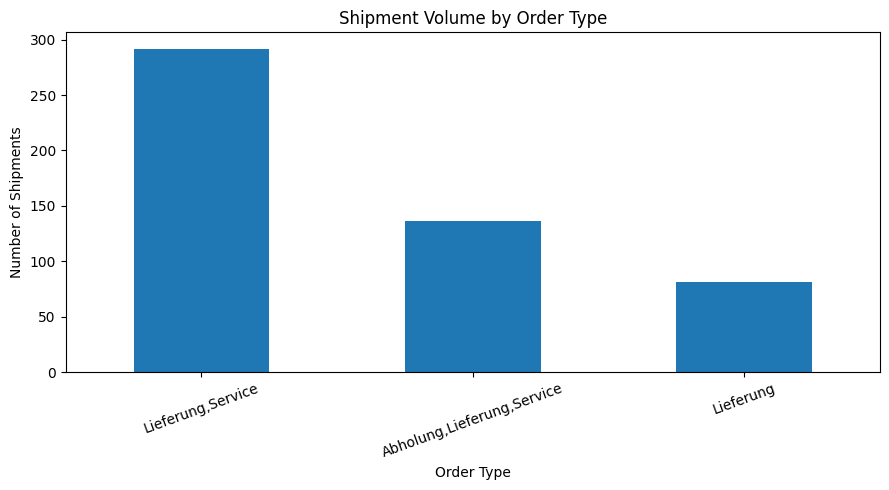

In [105]:
import matplotlib.pyplot as plt

order_counts = df_clean["Auftragsart"].value_counts()

plt.figure(figsize=(9, 5))
order_counts.plot(kind="bar")
plt.title("Shipment Volume by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

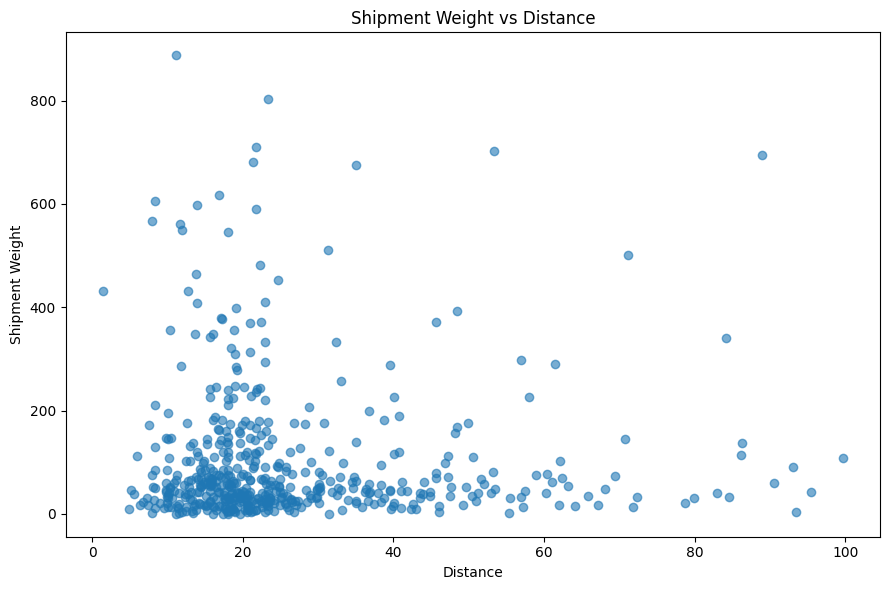

In [106]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Distanz (in m)"],
    df_clean["Gesamtgewicht pro Sendung"],
    alpha=0.6
)

plt.title("Shipment Weight vs Distance")
plt.xlabel("Distance")
plt.ylabel("Shipment Weight")
plt.tight_layout()
plt.show()

In [107]:
correlation = df_clean[
    ["Distanz (in m)", "Gesamtgewicht pro Sendung"]
].corr()

correlation

,Distanz (in m),Gesamtgewicht pro Sendung
Distanz (in m),1.000000,-0.011796
Gesamtgewicht pro Sendung,-0.011796,1.000000


In [108]:
correlation = df_clean[
    ["Distanz (in m)", "Gesamtgewicht pro Sendung"]
].corr()

correlation

,Distanz (in m),Gesamtgewicht pro Sendung
Distanz (in m),1.000000,-0.011796
Gesamtgewicht pro Sendung,-0.011796,1.000000


In [109]:
heavy_shipments = (
    df_clean[
        df_clean["Gesamtgewicht pro Sendung"] >= 300
    ][
        [
            "PLZ",
            "Gesamtgewicht pro Sendung",
            "Anzahl Verpackungseinheit",
            "Auftragsart",
            "Distanz (in m)",
            "building_levels_avg",
            "parking_count"
        ]
    ]
    .sort_values("Gesamtgewicht pro Sendung", ascending=False)
)

heavy_shipments

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
117,13587,888.0,3,Lieferung,11.2,0.0,0.0
272,16321,803.0,3,"Abholung,Lieferung,Service",23.3,1.5,0.0
109,14621,710.0,2,"Abholung,Lieferung,Service",21.8,0.0,0.0
214,10245,702.0,2,"Abholung,Lieferung,Service",53.4,5.2,24.0
509,13403,694.0,2,Lieferung,88.9,3.3,14.0
256,12359,682.0,2,Lieferung,21.4,0.0,42.0
4,15711,676.0,5,"Abholung,Lieferung,Service",35.0,1.0,0.0
405,12619,618.0,3,"Lieferung,Service",16.8,6.0,152.2
312,39524,606.0,2,"Abholung,Lieferung,Service",8.3,0.0,0.0
83,13507,598.0,3,"Lieferung,Service",13.9,4.0,1.0


In [110]:
heavy_summary = (
    df_clean[df_clean["Gesamtgewicht pro Sendung"] >= 300]
    .groupby("Auftragsart")
    .agg(
        heavy_shipments=("PLZ", "size"),
        avg_weight=("Gesamtgewicht pro Sendung", "mean"),
        avg_distance=("Distanz (in m)", "mean")
    )
    .sort_values("heavy_shipments", ascending=False)
)

heavy_summary

,heavy_shipments,avg_weight,avg_distance
Auftragsart,,,
"Lieferung,Service",19,416.842105,21.857895
"Abholung,Lieferung,Service",14,527.142857,24.721429
Lieferung,9,549.111111,31.277778


In [111]:
print("Heavy shipments:", len(heavy_shipments))
print("Share of all shipments:", round(len(heavy_shipments) / len(df_clean) * 100, 2), "%")

Heavy shipments: 42
Share of all shipments: 8.25 %


In [112]:
packaging_summary = (
    df_clean
    .groupby("Anzahl Verpackungseinheit")
    .agg(
        shipments=("PLZ", "size"),
        avg_weight=("Gesamtgewicht pro Sendung", "mean"),
        median_weight=("Gesamtgewicht pro Sendung", "median"),
        avg_distance=("Distanz (in m)", "mean")
    )
    .sort_index()
)

packaging_summary

,shipments,avg_weight,median_weight,avg_distance
Anzahl Verpackungseinheit,,,,
0,4,0.000000,0.0,19.500000
1,322,76.080745,44.0,26.807143
2,130,123.238462,58.0,24.513077
3,35,235.971429,115.0,27.645714
4,13,165.000000,108.0,24.153846
5,3,325.333333,160.0,24.133333
6,1,120.000000,120.0,18.000000
8,1,227.000000,227.0,15.700000


In [113]:
pack_weight_corr = df_clean[
    ["Anzahl Verpackungseinheit", "Gesamtgewicht pro Sendung"]
].corr()

pack_weight_corr

,Anzahl Verpackungseinheit,Gesamtgewicht pro Sendung
Anzahl Verpackungseinheit,1.000000,0.309613
Gesamtgewicht pro Sendung,0.309613,1.000000


In [114]:
df_clean[
    ["Anzahl Verpackungseinheit", "Gesamtgewicht pro Sendung"]
].corr().iloc[0, 1]


np.float64(0.30961331590595326)

In [115]:
plz_summary = (
    df_clean
    .groupby("PLZ")
    .agg(
        shipments=("PLZ", "size"),
        avg_weight=("Gesamtgewicht pro Sendung", "mean"),
        median_weight=("Gesamtgewicht pro Sendung", "median"),
        avg_distance=("Distanz (in m)", "mean"),
        avg_packaging=("Anzahl Verpackungseinheit", "mean")
    )
    .query("shipments >= 5")
    .sort_values("shipments", ascending=False)
)

plz_summary

,shipments,avg_weight,median_weight,avg_distance,avg_packaging
PLZ,,,,,
13046,16,174.812500,92.5,24.512500,1.500000
16816,10,112.700000,123.5,17.460000,1.200000
12353,9,46.111111,40.0,43.177778,1.222222
14974,8,103.375000,94.5,21.737500,1.500000
10437,8,24.875000,22.5,18.337500,1.875000
16727,8,93.750000,70.5,18.775000,1.500000
14469,7,69.142857,67.0,31.114286,1.142857
13465,7,87.857143,31.0,26.442857,1.142857
14712,7,166.285714,163.0,23.728571,1.571429


In [116]:
top_plz_volume = (
    df_clean
    .groupby("PLZ")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_plz_volume

,0
PLZ,
13046,16
16816,10
12353,9
14974,8
10437,8
16727,8
14469,7
14712,7
13465,7


In [117]:
top_plz_weight = (
    df_clean
    .groupby("PLZ")["Gesamtgewicht pro Sendung"]
    .agg(["count", "mean", "median"])
    .query("count >= 5")
    .sort_values("mean", ascending=False)
    .head(10)
)

top_plz_weight

,count,mean,median
PLZ,,,
15711,6,252.833333,133.0
10245,5,211.200000,48.0
13044,5,208.200000,242.0
14621,6,190.000000,87.0
13046,16,174.812500,92.5
12359,5,172.000000,54.0
14712,7,166.285714,163.0
13089,5,148.800000,118.0
16540,6,118.000000,60.5


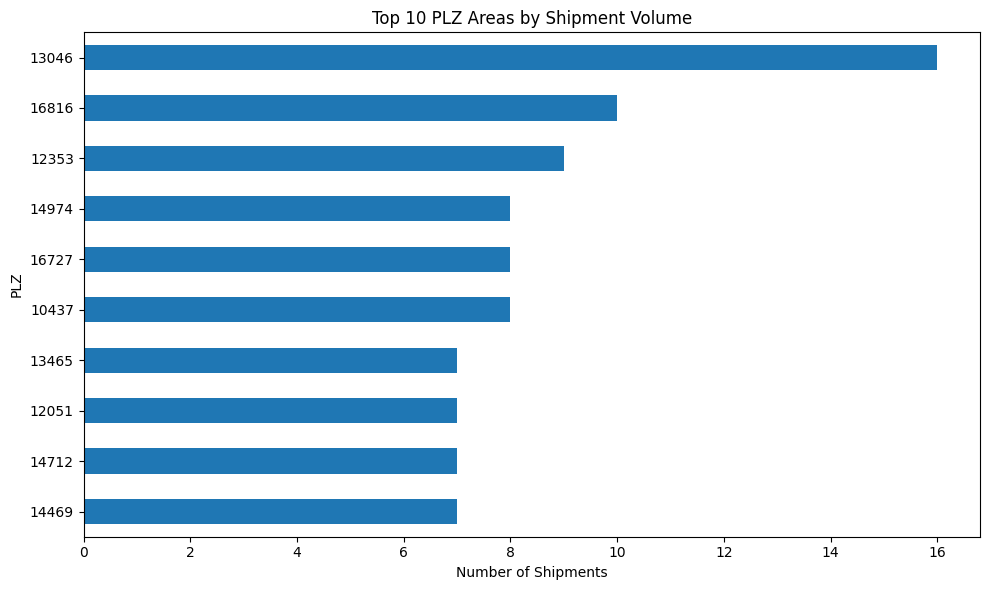

In [118]:
plt.figure(figsize=(10, 6))

top_plz_volume.sort_values().plot(kind="barh")

plt.title("Top 10 PLZ Areas by Shipment Volume")
plt.xlabel("Number of Shipments")
plt.ylabel("PLZ")
plt.tight_layout()
plt.show()

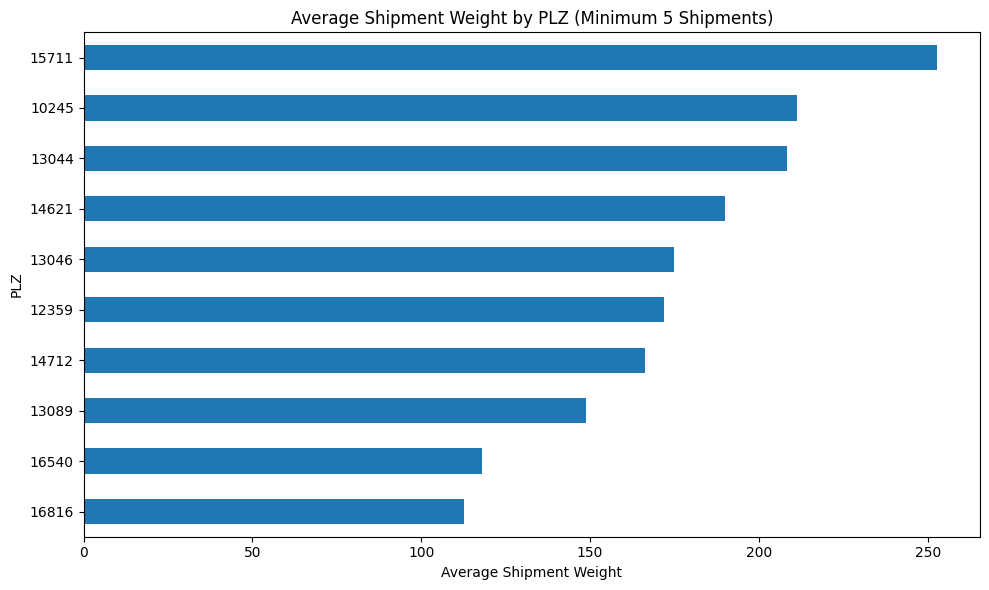

In [119]:
plz_weight_chart = top_plz_weight.sort_values("mean")

plt.figure(figsize=(10, 6))

plz_weight_chart["mean"].plot(kind="barh")

plt.title("Average Shipment Weight by PLZ (Minimum 5 Shipments)")
plt.xlabel("Average Shipment Weight")
plt.ylabel("PLZ")
plt.tight_layout()
plt.show()


In [120]:
environment_summary = df_clean[
    ["building_levels_avg", "parking_count",
     "Gesamtgewicht pro Sendung", "Distanz (in m)",
     "Anzahl Verpackungseinheit"]
].corr()

environment_summary

,building_levels_avg,parking_count,Gesamtgewicht pro Sendung,Distanz (in m),Anzahl Verpackungseinheit
building_levels_avg,1.000000,0.380477,-0.099469,0.043994,-0.002642
parking_count,0.380477,1.000000,-0.048937,-0.051219,0.026908
Gesamtgewicht pro Sendung,-0.099469,-0.048937,1.000000,-0.011796,0.309613
Distanz (in m),0.043994,-0.051219,-0.011796,1.000000,-0.038476
Anzahl Verpackungseinheit,-0.002642,0.026908,0.309613,-0.038476,1.000000


In [121]:
order_corr = (
    df_clean
    .groupby("Auftragsart")
    .apply(
        lambda x: x[
            ["Gesamtgewicht pro Sendung", "Anzahl Verpackungseinheit"]
        ].corr().iloc[0, 1]
    )
)

order_corr

/tmp/ipykernel_832/2769645557.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,0
Auftragsart,
"Abholung,Lieferung,Service",0.282922
Lieferung,0.420236
"Lieferung,Service",0.293972


In [122]:
order_corr = (
    df_clean
    .groupby("Auftragsart")
    .apply(
        lambda x: x[
            ["Gesamtgewicht pro Sendung", "Anzahl Verpackungseinheit"]
        ].corr().iloc[0, 1]
    )
)

order_corr

/tmp/ipykernel_832/2769645557.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,0
Auftragsart,
"Abholung,Lieferung,Service",0.282922
Lieferung,0.420236
"Lieferung,Service",0.293972


In [123]:
# Create the final clean dataset from the original dataframe

df_clean = df.drop_duplicates().copy()

# PLZ is an identifier, so store it as 5-character text
df_clean["PLZ"] = df_clean["PLZ"].astype(int).astype(str).str.zfill(5)

# Check the final structure
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Duplicates:", df_clean.duplicated().sum())
print("Missing values:", df_clean.isna().sum().sum())

print("\nPLZ length:")
print(df_clean["PLZ"].str.len().value_counts())

Rows: 509
Columns: 7
Duplicates: 0
Missing values: 0

PLZ length:
PLZ
5    509
Name: count, dtype: int64


In [124]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 509 entries, 0 to 509
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PLZ                        509 non-null    object 
 1   Gesamtgewicht pro Sendung  509 non-null    float64
 2   Anzahl Verpackungseinheit  509 non-null    int64  
 3   Auftragsart                509 non-null    object 
 4   Distanz (in m)             509 non-null    float64
 5   building_levels_avg        509 non-null    float64
 6   parking_count              509 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 31.8+ KB


In [125]:
df_clean.head()

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
0,15745,182.0,3,"Abholung,Lieferung,Service",38.7,2.5,20.0
1,15745,68.0,2,"Abholung,Lieferung,Service",15.9,1.2,14.0
2,15711,54.0,1,"Abholung,Lieferung,Service",14.4,1.9,30.0
3,15711,69.0,2,"Abholung,Lieferung,Service",14.4,1.9,30.0
4,15711,676.0,5,"Abholung,Lieferung,Service",35.0,1.0,0.0


In [126]:
output_path = "/content/berlin_logistics_clean.csv"

df_clean.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(df_clean))

Saved: /content/berlin_logistics_clean.csv
Rows: 509


In [127]:
import sqlite3

db_path = "/content/berlin_logistics.db"

conn = sqlite3.connect(db_path)

df_clean.to_sql(
    "shipments",
    conn,
    if_exists="replace",
    index=False
)

print("Database created:", db_path)
print("Table created: shipments")

Database created: /content/berlin_logistics.db
Table created: shipments


In [128]:
query = """
SELECT *
FROM shipments
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,PLZ,Gesamtgewicht pro Sendung,Anzahl Verpackungseinheit,Auftragsart,Distanz (in m),building_levels_avg,parking_count
0,15745,182.0,3,"Abholung,Lieferung,Service",38.7,2.5,20.0
1,15745,68.0,2,"Abholung,Lieferung,Service",15.9,1.2,14.0
2,15711,54.0,1,"Abholung,Lieferung,Service",14.4,1.9,30.0
3,15711,69.0,2,"Abholung,Lieferung,Service",14.4,1.9,30.0
4,15711,676.0,5,"Abholung,Lieferung,Service",35.0,1.0,0.0


In [129]:
query = """
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count
FROM shipments
GROUP BY Auftragsart
ORDER BY shipment_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Auftragsart,shipment_count
0,"Lieferung,Service",292
1,"Abholung,Lieferung,Service",136
2,Lieferung,81


In [130]:
query = """
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count,
    SUM("Gesamtgewicht pro Sendung") AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight
FROM shipments
GROUP BY Auftragsart
ORDER BY total_weight DESC;
"""

result = pd.read_sql_query(query, conn)

result


,Auftragsart,shipment_count,total_weight,avg_weight
0,"Lieferung,Service",292,26230.0,89.83
1,"Abholung,Lieferung,Service",136,18121.0,133.24
2,Lieferung,81,7895.0,97.47


In [131]:
query = """
SELECT
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(
        (
            SUM(
                ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                *
                ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
            )
            /
            (
                SQRT(
                    SUM(
                        ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                        *
                        ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                    )
                )
                *
                SQRT(
                    SUM(
                        ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
                        *
                        ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
                    )
                )
            )
        ), 3
    ) AS weight_distance_correlation
FROM shipments;
"""

result = pd.read_sql_query(query, conn)

result

,avg_distance,avg_weight,weight_distance_correlation
0,26.1,102.64,-0.012


In [132]:
query = """
SELECT
    Auftragsart,
    COUNT(*) AS heavy_shipments,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_heavy_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
WHERE "Gesamtgewicht pro Sendung" >= 300
GROUP BY Auftragsart
ORDER BY heavy_shipments DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Auftragsart,heavy_shipments,avg_heavy_weight,avg_distance
0,"Lieferung,Service",19,416.84,21.86
1,"Abholung,Lieferung,Service",14,527.14,24.72
2,Lieferung,9,549.11,31.28


In [133]:
query = """
SELECT
    PLZ,
    COUNT(*) AS shipment_count,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
GROUP BY PLZ
HAVING COUNT(*) >= 5
ORDER BY shipment_count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,PLZ,shipment_count,avg_weight,avg_distance
0,03046,16,174.81,24.51
1,16816,10,112.70,17.46
2,16727,8,93.75,18.78
3,10437,8,24.88,18.34
4,14974,7,105.71,22.80
5,14712,7,166.29,23.73
6,14469,7,69.14,31.11
7,13465,7,87.86,26.44
8,16540,6,118.00,15.52
9,15711,6,252.83,23.33


In [134]:
query = """
SELECT
    "Anzahl Verpackungseinheit" AS packaging_units,
    COUNT(*) AS shipment_count,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
GROUP BY "Anzahl Verpackungseinheit"
ORDER BY packaging_units;
"""

result = pd.read_sql_query(query, conn)

result

,packaging_units,shipment_count,avg_weight,avg_distance
0,0,4,0.00,19.50
1,1,322,76.08,26.81
2,2,130,123.24,24.51
3,3,35,235.97,27.65
4,4,13,165.00,24.15
5,5,3,325.33,24.13
6,6,1,120.00,18.00
7,8,1,227.00,15.70


In [135]:
query = """
SELECT
    COUNT(*) AS total_shipments,
    COUNT(DISTINCT PLZ) AS unique_plz,
    ROUND(SUM("Gesamtgewicht pro Sendung"), 2) AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Anzahl Verpackungseinheit"), 2) AS avg_packaging_units
FROM shipments;
"""

result = pd.read_sql_query(query, conn)

result

,total_shipments,unique_plz,total_weight,avg_weight,avg_distance,avg_packaging_units
0,509,226,52246.0,102.64,26.1,1.51


In [136]:
# Rebuild PLZ using the pattern we identified during data validation

import pandas as pd
import csv

file_path = "/content/sample_data/Berlin_Traffic_data _set .csv"

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

columns = next(csv.reader([lines[0].strip()]))

data = []
for line in lines[1:]:
    line = line.strip()
    line = line[1:-1]
    line = line.replace('""', '"')
    row = next(csv.reader([line]))
    data.append(row)

df = pd.DataFrame(data, columns=columns)

numeric_cols = [
    "Gesamtgewicht pro Sendung",
    "Anzahl Verpackungseinheit",
    "Distanz (in m)",
    "building_levels_avg",
    "parking_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.drop_duplicates().copy()

# Correct PLZ representation
def fix_plz(x):
    s = str(int(float(x)))

    if len(s) == 5:
        return s
    elif len(s) == 4:
        if s.startswith("1"):
            return "0" + s
        else:
            return "1" + s
    elif len(s) == 3:
        return "10" + s
    else:
        return s.zfill(5)

df_clean["PLZ"] = df_clean["PLZ"].apply(fix_plz)

print("Rows:", len(df_clean))
print("Unique PLZ:", df_clean["PLZ"].nunique())
print("PLZ lengths:")
print(df_clean["PLZ"].str.len().value_counts())

Rows: 509
Unique PLZ: 192
PLZ lengths:
PLZ
5    509
Name: count, dtype: int64


In [137]:
# Inspect the original short PLZ values
original_plz = df["PLZ"].astype(int).astype(str)

print("4-digit PLZ values:")
print(sorted(original_plz[original_plz.str.len() == 4].unique()))

print("\n3-digit PLZ values:")
print(sorted(original_plz[original_plz.str.len() == 3].unique()))

4-digit PLZ values:
['2043', '2045', '2049', '2051', '2053', '2055', '2099', '2101', '2103', '2105', '2107', '2109', '2203', '2249', '2277', '2305', '2307', '2309', '2347', '2349', '2351', '2353', '2357', '2359', '2435', '2437', '2439', '2459', '2489', '2526', '2527', '2529', '2555', '2557', '2587', '2623', '3042', '3044', '3046', '3048', '3050', '3052', '3055', '3099', '3222', '3347', '3403', '3587', '4163', '4167', '4513', '4532', '4612', '4621', '4974', '4979', '5732']

3-digit PLZ values:
['115', '318', '405', '551', '827']


In [138]:
short_4 = sorted(
    original_plz[original_plz.str.len() == 4].unique()
)

print("4-digit PLZ starting with 1:")
print([x for x in short_4 if x.startswith("1")])

print("\nCount:")
print(sum(x.startswith("1") for x in short_4))

4-digit PLZ starting with 1:
[]

Count:
0


In [139]:
# Check which original PLZ values become the same after our transformation

test_plz = pd.DataFrame({
    "original": original_plz.unique()
})

def transform_plz(s):
    if len(s) == 5:
        return s
    elif len(s) == 4:
        return "1" + s
    elif len(s) == 3:
        return "10" + s
    else:
        return s.zfill(5)

test_plz["transformed"] = test_plz["original"].apply(transform_plz)

collisions = (
    test_plz
    .groupby("transformed")
    .filter(lambda x: len(x) > 1)
    .sort_values("transformed")
)

print("Number of collisions:", collisions["transformed"].nunique())
print("\nColliding PLZ:")
print(collisions.to_string(index=False))

Number of collisions: 34

Colliding PLZ:
original transformed
     115       10115
   10115       10115
     318       10318
   10318       10318
     405       10405
   10405       10405
     551       10551
   10551       10551
     827       10827
   10827       10827
   12043       12043
    2043       12043
   12045       12045
    2045       12045
    2049       12049
   12049       12049
    2051       12051
   12051       12051
   12053       12053
    2053       12053
    2055       12055
   12055       12055
    2099       12099
   12099       12099
    2103       12103
   12103       12103
    2107       12107
   12107       12107
    2249       12249
   12249       12249
   12347       12347
    2347       12347
   12349       12349
    2349       12349
    2351       12351
   12351       12351
   12353       12353
    2353       12353
   12359       12359
    2359       12359
   12437       12437
    2437       12437
    2439       12439
   12439       12439
   12489      

In [140]:
# Restore PLZ using source-preserving formatting
df_clean = df.drop_duplicates().copy()

df_clean["PLZ"] = (
    df_clean["PLZ"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

print("Rows:", len(df_clean))
print("Unique PLZ:", df_clean["PLZ"].nunique())
print("\nPLZ lengths:")
print(df_clean["PLZ"].str.len().value_counts())

Rows: 509
Unique PLZ: 226

PLZ lengths:
PLZ
5    509
Name: count, dtype: int64


In [141]:
# Replace the SQL table with the corrected dataframe

df_clean.to_sql(
    "shipments",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite table updated successfully.")
print("Rows:", len(df_clean))
print("Unique PLZ:", df_clean["PLZ"].nunique())

SQLite table updated successfully.
Rows: 509
Unique PLZ: 226


In [142]:
query = """
SELECT
    COUNT(*) AS total_shipments,
    COUNT(DISTINCT PLZ) AS unique_plz,
    ROUND(SUM("Gesamtgewicht pro Sendung"), 2) AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Anzahl Verpackungseinheit"), 2) AS avg_packaging_units
FROM shipments;
"""

result = pd.read_sql_query(query, conn)

result

,total_shipments,unique_plz,total_weight,avg_weight,avg_distance,avg_packaging_units
0,509,226,52246.0,102.64,26.1,1.51


In [143]:
sql_script = """
-- Berlin Logistics Intelligence
-- SQL Analysis
-- Dataset: 509 cleaned shipment records

-- Query 1: Shipment volume by order type
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count
FROM shipments
GROUP BY Auftragsart
ORDER BY shipment_count DESC;


-- Query 2: Weight by order type
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count,
    SUM("Gesamtgewicht pro Sendung") AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight
FROM shipments
GROUP BY Auftragsart
ORDER BY total_weight DESC;


-- Query 3: Distance and weight correlation
SELECT
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(
        (
            SUM(
                ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                *
                ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
            )
            /
            (
                SQRT(SUM(
                    ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                    *
                    ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                ))
                *
                SQRT(SUM(
                    ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
                    *
                    ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
                ))
            )
        ), 3
    ) AS weight_distance_correlation
FROM shipments;


-- Query 4: Heavy shipments (weight >= 300)
SELECT
    Auftragsart,
    COUNT(*) AS heavy_shipments,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_heavy_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
WHERE "Gesamtgewicht pro Sendung" >= 300
GROUP BY Auftragsart
ORDER BY heavy_shipments DESC;


-- Query 5: Highest-volume PLZ areas
-- Minimum 5 shipments to avoid very small samples
SELECT
    PLZ,
    COUNT(*) AS shipment_count,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
GROUP BY PLZ
HAVING COUNT(*) >= 5
ORDER BY shipment_count DESC
LIMIT 10;


-- Query 6: Packaging units vs shipment weight
SELECT
    "Anzahl Verpackungseinheit" AS packaging_units,
    COUNT(*) AS shipment_count,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance
FROM shipments
GROUP BY "Anzahl Verpackungseinheit"
ORDER BY packaging_units;


-- Query 7: Overall KPIs
SELECT
    COUNT(*) AS total_shipments,
    COUNT(DISTINCT PLZ) AS unique_plz,
    ROUND(SUM("Gesamtgewicht pro Sendung"), 2) AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Anzahl Verpackungseinheit"), 2) AS avg_packaging_units
FROM shipments;
"""

sql_path = "/content/analysis.sql"

with open(sql_path, "w", encoding="utf-8") as f:
    f.write(sql_script)

print("SQL file created:", sql_path)

SQL file created: /content/analysis.sql


In [144]:
with open("/content/analysis.sql", "r", encoding="utf-8") as f:
    print(f.read())


-- Berlin Logistics Intelligence
-- SQL Analysis
-- Dataset: 509 cleaned shipment records

-- Query 1: Shipment volume by order type
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count
FROM shipments
GROUP BY Auftragsart
ORDER BY shipment_count DESC;


-- Query 2: Weight by order type
SELECT
    Auftragsart,
    COUNT(*) AS shipment_count,
    SUM("Gesamtgewicht pro Sendung") AS total_weight,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight
FROM shipments
GROUP BY Auftragsart
ORDER BY total_weight DESC;


-- Query 3: Distance and weight correlation
SELECT
    ROUND(AVG("Distanz (in m)"), 2) AS avg_distance,
    ROUND(AVG("Gesamtgewicht pro Sendung"), 2) AS avg_weight,
    ROUND(
        (
            SUM(
                ("Distanz (in m)" - (SELECT AVG("Distanz (in m)") FROM shipments))
                *
                ("Gesamtgewicht pro Sendung" - (SELECT AVG("Gesamtgewicht pro Sendung") FROM shipments))
            )
            /
            (
                SQRT(

In [145]:
dashboard_df = df_clean.copy()

dashboard_df.columns = [
    "PLZ",
    "shipment_weight",
    "packaging_units",
    "order_type",
    "distance",
    "building_levels_avg",
    "parking_count"
]

dashboard_path = "/content/berlin_logistics_dashboard.csv"

dashboard_df.to_csv(
    dashboard_path,
    index=False
)

print("Dashboard CSV created:", dashboard_path)
print("Rows:", len(dashboard_df))
print("Columns:", list(dashboard_df.columns))

Dashboard CSV created: /content/berlin_logistics_dashboard.csv
Rows: 509
Columns: ['PLZ', 'shipment_weight', 'packaging_units', 'order_type', 'distance', 'building_levels_avg', 'parking_count']


In [146]:
from google.colab import files

files.download("/content/berlin_logistics_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SQL Analysis



In [147]:
import sqlite3

conn = sqlite3.connect("/content/berlin_logistics.db")

df_clean.to_sql(
    "shipments",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")
print("Rows:", pd.read_sql(
    "SELECT COUNT(*) AS rows FROM shipments",
    conn
).iloc[0, 0])

Database created successfully.
Rows: 509


## Key Findings

- The dataset contains **509 shipments** across **226 unique PLZ areas**.
- Total shipment weight is **52,246**.
- Average shipment weight is **102.64**, while the median is **52**, indicating a right-skewed distribution with some heavy shipments.
- `Lieferung,Service` is the most common order type, representing about **57%** of shipments.
- **42 shipments (8.25%)** have a shipment weight of at least 300.
- Shipment weight and distance show **almost no linear correlation** (r ≈ -0.012).
- Packaging units show a **moderate positive association** with shipment weight (r ≈ 0.31).


## SQL Analysis

The cleaned dataset was loaded into a SQLite database and analyzed using SQL.

The analysis covers:

1. Shipment volume by order type
2. Shipment weight by order type
3. Weight and distance relationship
4. Heavy shipment identification
5. Top PLZ areas by shipment volume
6. Packaging units and shipment weight
7. Overall operational KPIs

The SQL queries are stored in `analysis.sql`.

## Dashboard

The project includes an interactive dashboard built in Looker Studio.

### Executive Overview
- Total shipments
- Total shipment weight
- Average shipment weight
- Average distance
- Shipment volume by order type
- Top 10 PLZ areas by shipment volume
- Average shipment weight by order type

### Operational Analysis
- Heavy shipments (≥300)
- Heavy shipment share
- Packaging units vs shipment weight
- Average shipment weight vs distance by PLZ

## Limitations & Notes

- The dataset does not include a postal-code reference table, so PLZ values were normalized to a 5-character format without inventing geographic corrections.
- Zero values were retained because the source data does not provide enough information to determine whether they represent valid operational values or unknown measurements.
- Correlation analysis indicates association only and does not imply causation.
- The dashboard is intended for operational exploration and portfolio demonstration rather than real-world logistics decision-making.

## Project Outputs

- `berlin_logistics_clean.csv` — cleaned dataset
- `berlin_logistics_dashboard.csv` — dashboard-ready dataset
- `berlin_logistics.db` — SQLite database
- `analysis.sql` — SQL analysis queries
- Looker Studio dashboard — interactive visualization